In [1]:
# Install required libraries
%pip install pandas numpy matplotlib seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline


In [3]:
# Load the dataset
path = r'C:\Users\Admin\Desktop\SCHOOL STUFF\Python\NHANES EDA\NHANES.csv'
db = pd.read_csv(path)

In [4]:
# Preview the first 5 rows of the raw dataset
db.head()

,SEQN,ALQ101,ALQ110,ALQ130,SMQ020,RIAGENDR,RIDAGEYR,RIDRETH1,DMDCITZN,DMDEDUC2,...,BPXSY2,BPXDI2,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,HIQ210
0,83732,1.0,NaN,1.0,1,1,62,3,1.0,5.0,...,124.0,64.0,94.8,184.5,27.8,43.3,43.6,35.9,101.1,2.0
1,83733,1.0,NaN,6.0,1,1,53,3,2.0,3.0,...,140.0,88.0,90.4,171.4,30.8,38.0,40.0,33.2,107.9,NaN
2,83734,1.0,NaN,NaN,1,1,78,3,1.0,3.0,...,132.0,44.0,83.4,170.1,28.8,35.6,37.0,31.0,116.5,2.0
3,83735,2.0,1.0,1.0,2,2,56,3,1.0,5.0,...,134.0,68.0,109.8,160.9,42.4,38.5,37.7,38.3,110.1,2.0
4,83736,2.0,1.0,1.0,2,2,42,4,1.0,4.0,...,114.0,54.0,55.2,164.9,20.3,37.4,36.0,27.2,80.4,2.0


In [5]:
# Check total rows and columns
db.shape

(5735, 28)

In [6]:
# List all column names
db.columns

Index(['SEQN', 'ALQ101', 'ALQ110', 'ALQ130', 'SMQ020', 'RIAGENDR', 'RIDAGEYR',
       'RIDRETH1', 'DMDCITZN', 'DMDEDUC2', 'DMDMARTL', 'DMDHHSIZ', 'WTINT2YR',
       'SDMVPSU', 'SDMVSTRA', 'INDFMPIR', 'BPXSY1', 'BPXDI1', 'BPXSY2',
       'BPXDI2', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC',
       'BMXWAIST', 'HIQ210'],
      dtype='str')

In [7]:
# Select only the 8 columns needed for analysis
data = db.loc[:, ('SEQN', 'SMQ020', 'RIAGENDR', 'RIDAGEYR', 'DMDEDUC2', 'BMXWT', 'BMXHT', 'BMXBMI')]
data.head()

,SEQN,SMQ020,RIAGENDR,RIDAGEYR,DMDEDUC2,BMXWT,BMXHT,BMXBMI
0,83732,1,1,62,5.0,94.8,184.5,27.8
1,83733,1,1,53,3.0,90.4,171.4,30.8
2,83734,1,1,78,3.0,83.4,170.1,28.8
3,83735,2,2,56,5.0,109.8,160.9,42.4
4,83736,2,2,42,4.0,55.2,164.9,20.3


In [8]:
# Check column data types and non-null counts
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5735 entries, 0 to 5734
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      5735 non-null   int64  
 1   SMQ020    5735 non-null   int64  
 2   RIAGENDR  5735 non-null   int64  
 3   RIDAGEYR  5735 non-null   int64  
 4   DMDEDUC2  5474 non-null   float64
 5   BMXWT     5666 non-null   float64
 6   BMXHT     5673 non-null   float64
 7   BMXBMI    5662 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 358.6 KB


In [9]:
# Rename columns to readable names
data = data.rename(columns = {
    'SEQN': 'id',
    'SMQ020': 'smoking',
    'RIAGENDR': 'gender',
    'RIDAGEYR': 'age',
    'DMDEDUC2': 'education',
    'BMXWT': 'weight',
    'BMXHT': 'height',
    'BMXBMI': 'bmi'
})

In [10]:
# Confirm renaming worked
data.head()

,id,smoking,gender,age,education,weight,height,bmi
0,83732,1,1,62,5.0,94.8,184.5,27.8
1,83733,1,1,53,3.0,90.4,171.4,30.8
2,83734,1,1,78,3.0,83.4,170.1,28.8
3,83735,2,2,56,5.0,109.8,160.9,42.4
4,83736,2,2,42,4.0,55.2,164.9,20.3


In [11]:
# Confirm shape after column selection
data.shape

(5735, 8)

In [12]:
# Check for duplicate rows
duplicates = data[data.duplicated()]
duplicates

,id,smoking,gender,age,education,weight,height,bmi


In [13]:
# Count unique values per column to spot ID columns and categoricals
unique = data.nunique().sort_values()
unique

gender          2
smoking         4
education       6
age            63
bmi           393
height        509
weight        997
id           5735
dtype: int64

### Data Cleaning

In [14]:
# Drop the ID column — not needed for analysis
data.drop('id', axis=1, inplace=True)


In [15]:
# Confirm ID column was dropped
data.head()

,smoking,gender,age,education,weight,height,bmi
0,1,1,62,5.0,94.8,184.5,27.8
1,1,1,53,3.0,90.4,171.4,30.8
2,1,1,78,3.0,83.4,170.1,28.8
3,2,2,56,5.0,109.8,160.9,42.4
4,2,2,42,4.0,55.2,164.9,20.3


In [16]:
# Check missing values as a percentage of total rows
(data.isnull().sum()/len(data) * 100).round(1)

smoking      0.0
gender       0.0
age          0.0
education    4.6
weight       1.2
height       1.1
bmi          1.3
dtype: float64

In [17]:
# Drop all rows with any missing values
data.dropna(inplace=True)

In [18]:
# Confirm rows remaining after dropping nulls
data.shape

(5406, 7)

In [19]:
# Summary statistics for numerical columns
numerical = ['age', 'weight', 'height', 'bmi']
data[numerical].describe().round(2)

,age,weight,height,bmi
count,5406.00,5406.00,5406.00,5406.00
mean,49.39,81.72,166.06,29.54
std,17.64,21.78,10.11,7.08
min,20.00,32.40,129.70,14.50
25%,34.00,66.30,158.60,24.50
50%,49.00,78.50,165.90,28.50
75%,64.00,93.20,173.40,33.20
max,80.00,198.90,202.70,67.30


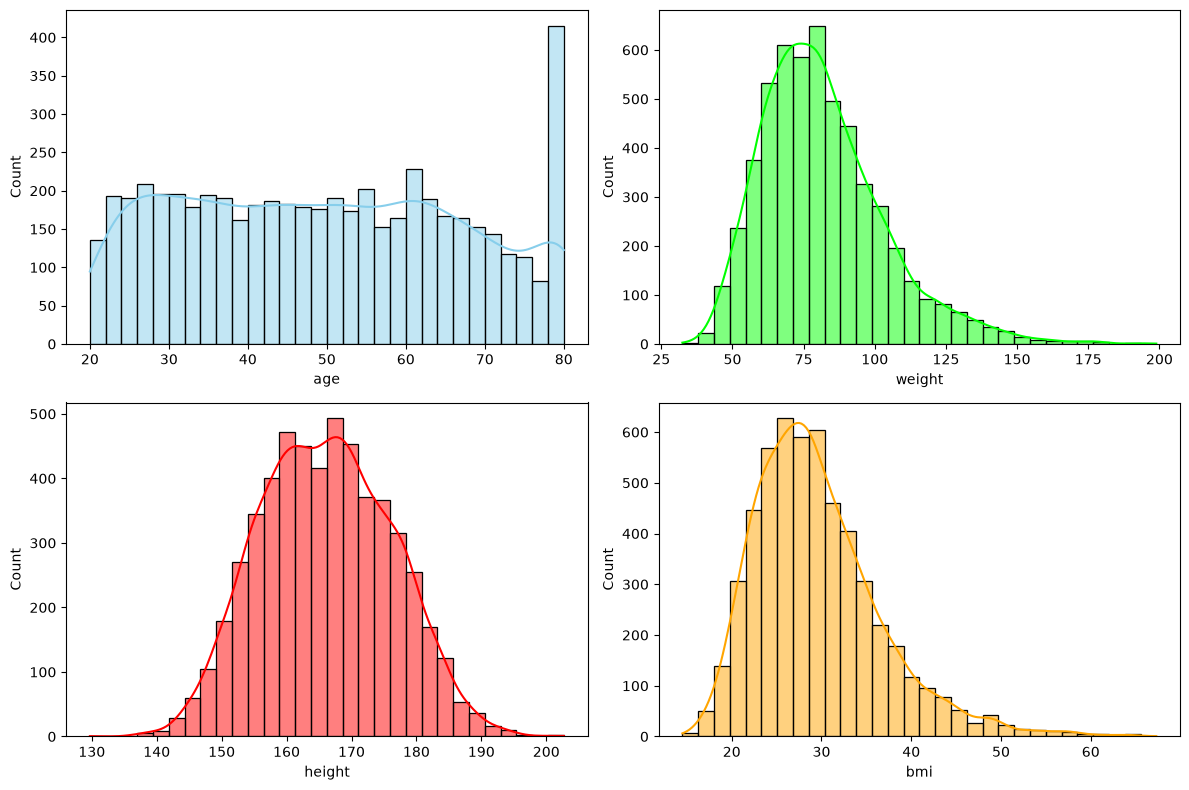

In [20]:
# Histograms — check the distribution shape of each numerical variable
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=data, x='age', kde=True, bins=30, ax=axes[0, 0], color='skyblue')
sns.histplot(data=data, x='weight', kde=True, color='lime', bins=30, ax=axes[0, 1])
sns.histplot(data=data, x='height', kde=True, color='red', bins=30, ax=axes[1, 0])
sns.histplot(data=data, x='bmi', kde=True, color='orange', bins=30, ax=axes[1, 1])
plt.tight_layout()


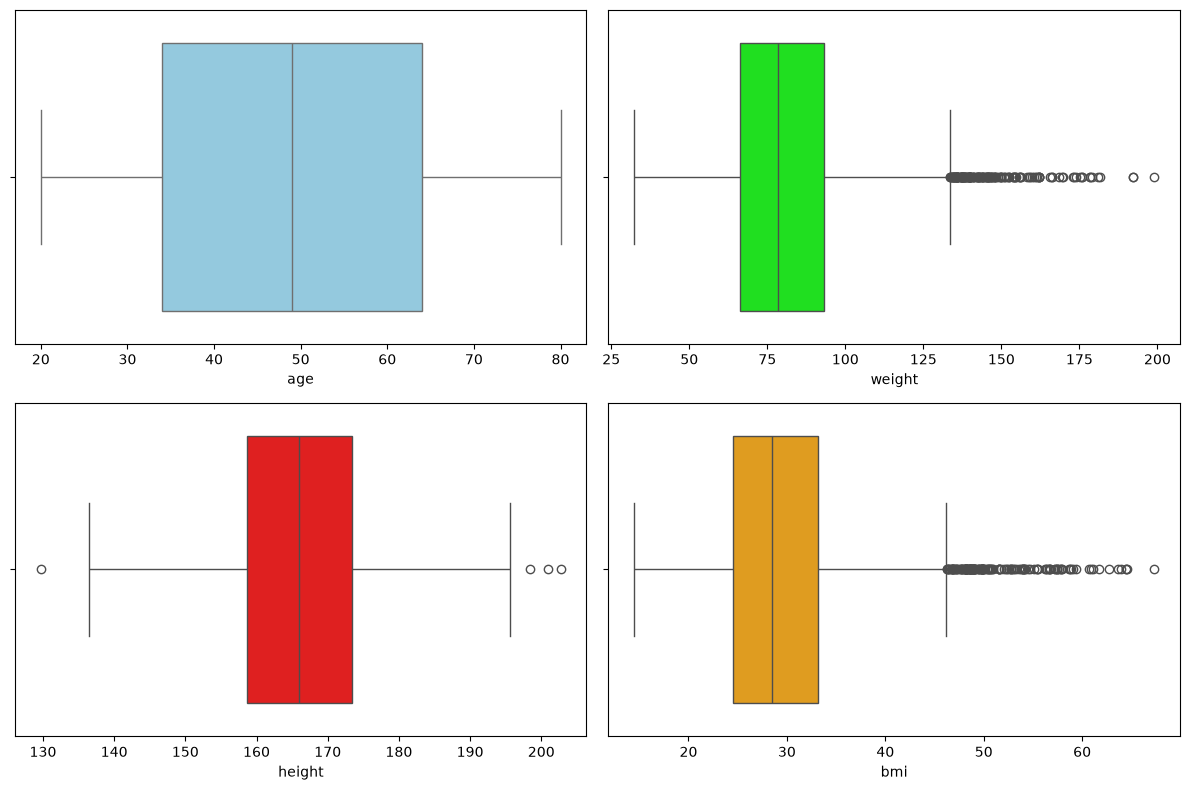

In [21]:
# Boxplots — check spread and outliers before cleaning
fig, axes=plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(data=data, x='age', ax=axes[0, 0], color = 'skyblue')
sns.boxplot(data=data, x='weight', ax=axes[0,1], color = 'lime')
sns.boxplot(data=data, x='height', ax=axes[1,0], color = 'red')
sns.boxplot(data=data, x='bmi', ax=axes[1,1], color = 'orange')
plt.tight_layout()

In [22]:
# Remove height outliers using the IQR method
hq25, hq50, hq75 = data['height'].quantile([0.25, 0.5, 0.75]).round(2)
hiqr = hq75 - hq25
hlower_bound = hq25 - 1.5 * hiqr
hupper_bound = hq75 + 1.5 * hiqr
print(f"Height Quantiles:\n Q1: {hq25} Q2: {hq50} Q3: {hq75}\n IQR: {hiqr}\n Lower Bound: {hlower_bound}\n Upper Bound: {hupper_bound}\n")

data=data[(data['height'] >= hlower_bound) & (data['height'] <= hupper_bound)]

Height Quantiles:
 Q1: 158.6 Q2: 165.9 Q3: 173.4
 IQR: 14.800000000000011
 Lower Bound: 136.39999999999998
 Upper Bound: 195.60000000000002



In [23]:
# Remove weight outliers using the IQR method
wq25, wq50, wq75 = data['weight'].quantile([0.25, 0.5, 0.75]).round(2)
wiqr = wq75 - wq25
wlower_bound = wq25 - 1.5 * wiqr
wupper_bound = wq75 + 1.5 * wiqr
print(f"Weight Quantiles:\n Q1: {wq25} Q2: {wq50} Q3: {wq75}\n IQR: {wiqr}\n Lower Bound: {wlower_bound}\n Upper Bound: {wupper_bound}\n")

data=data[(data['weight'] <= wupper_bound)]

Weight Quantiles:
 Q1: 66.3 Q2: 78.5 Q3: 93.1
 IQR: 26.799999999999997
 Lower Bound: 26.1
 Upper Bound: 133.29999999999998



In [24]:
# Remove BMI outliers using the IQR method
bq25, bq50, bq75 = data['bmi'].quantile([0.25, 0.5, 0.75]).round(2)
biqr = bq75 - bq25
blower_bound = bq25 - 1.5 * biqr
bupper_bound = bq75 + 1.5 * biqr
print(f"BMI Quantiles:\n Q1: {bq25} Q2: {bq50} Q3: {bq75}\n IQR: {biqr}\n Lower Bound: {blower_bound}\n Upper Bound: {bupper_bound}\n")

data=data[(data['bmi'] <= bupper_bound)]

BMI Quantiles:
 Q1: 24.4 Q2: 28.2 Q3: 32.7
 IQR: 8.300000000000004
 Lower Bound: 11.949999999999992
 Upper Bound: 45.150000000000006



In [25]:
# Confirm rows remaining after outlier removal
data.shape

(5171, 7)

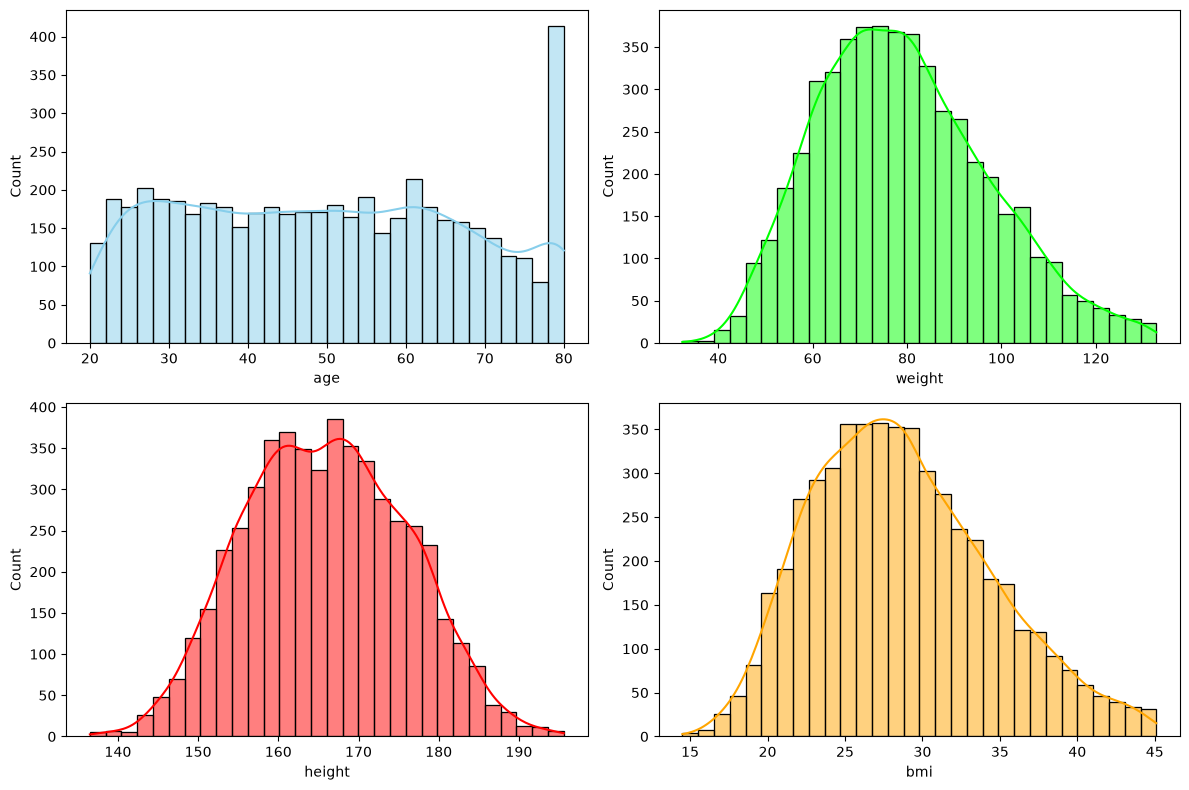

In [26]:
# Histograms after outlier removal — distributions should look cleaner
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=data, x='age', kde=True, bins=30, ax=axes[0, 0], color='skyblue')
sns.histplot(data=data, x='weight', kde=True, color='lime', bins=30, ax=axes[0, 1])
sns.histplot(data=data, x='height', kde=True, color='red', bins=30, ax=axes[1, 0])
sns.histplot(data=data, x='bmi', kde=True, color='orange', bins=30, ax=axes[1, 1])
plt.tight_layout()

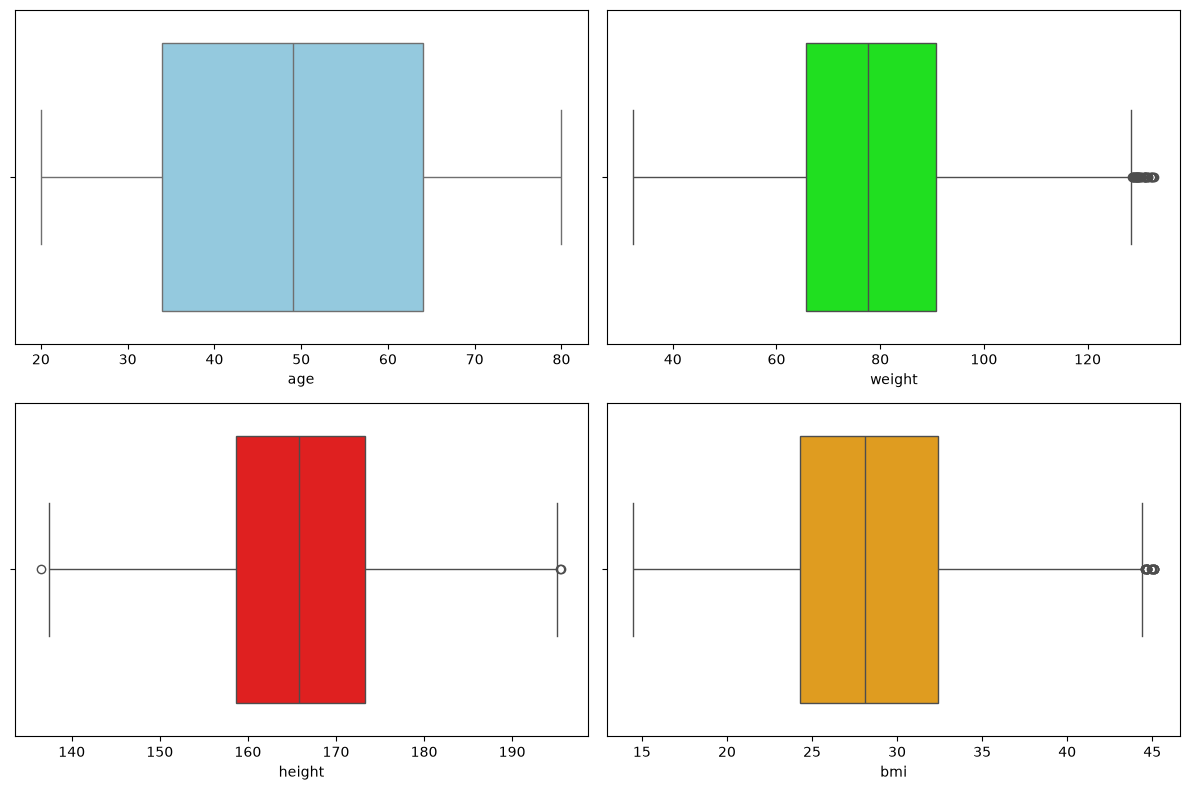

In [27]:
# Boxplots after outlier removal — fewer extreme dots expected
fig, axes=plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(data=data, x='age', ax=axes[0, 0], color = 'skyblue')
sns.boxplot(data=data, x='weight', ax=axes[0,1], color = 'lime')
sns.boxplot(data=data, x='height', ax=axes[1,0], color = 'red')
sns.boxplot(data=data, x='bmi', ax=axes[1,1], color = 'orange')
plt.tight_layout()

In [28]:
# Inspect raw numeric codes in categorical columns before mapping
print("Smoking unique:", data['smoking'].unique())
print("Gender unique:", data['gender'].unique())
print("Education unique:", data['education'].unique())


Smoking unique: [1 2 7 9]
Gender unique: [1 2]
Education unique: [5. 3. 4. 2. 1. 9.]


In [29]:
# Map numeric codes to readable labels for smoking, gender and education
data['smoking'] = data['smoking'].replace({1: 'Yes', 2: 'No', 7: np.nan, 9: np.nan})
data['gender'] = data['gender'].replace({1: 'Male', 2: 'Female'})
data['education'] = data['education'].replace({1: 'Less than 9th grade', 2: '9th to 12th grade', 3: 'High school graduate', 4: 'Some college', 5: 'College graduate', 9: 'Others'})


In [30]:
# Isolate categorical columns
categorical = data.select_dtypes(include='object')
categorical.head()

,smoking,gender,education
0,Yes,Male,College graduate
1,Yes,Male,High school graduate
2,Yes,Male,High school graduate
3,No,Female,College graduate
4,No,Female,Some college


In [31]:
# Isolate numerical columns
numerical = data.select_dtypes(include='number')
numerical.head()

,age,weight,height,bmi
0,62,94.8,184.5,27.8
1,53,90.4,171.4,30.8
2,78,83.4,170.1,28.8
3,56,109.8,160.9,42.4
4,42,55.2,164.9,20.3


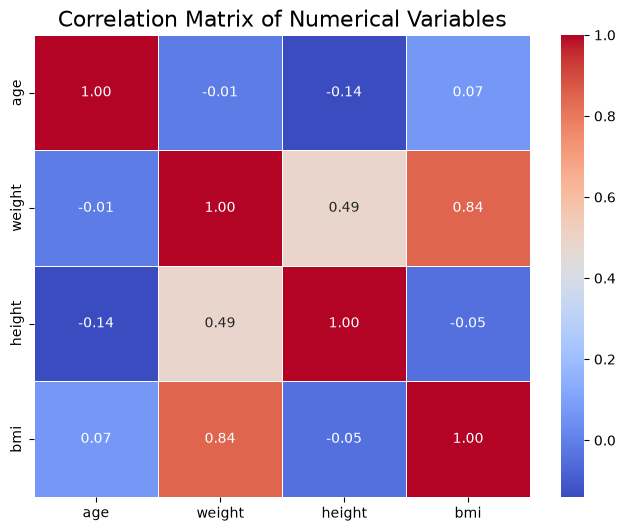

In [32]:
# Correlation heatmap — shows relationships between numerical variables
corr = numerical.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.show()

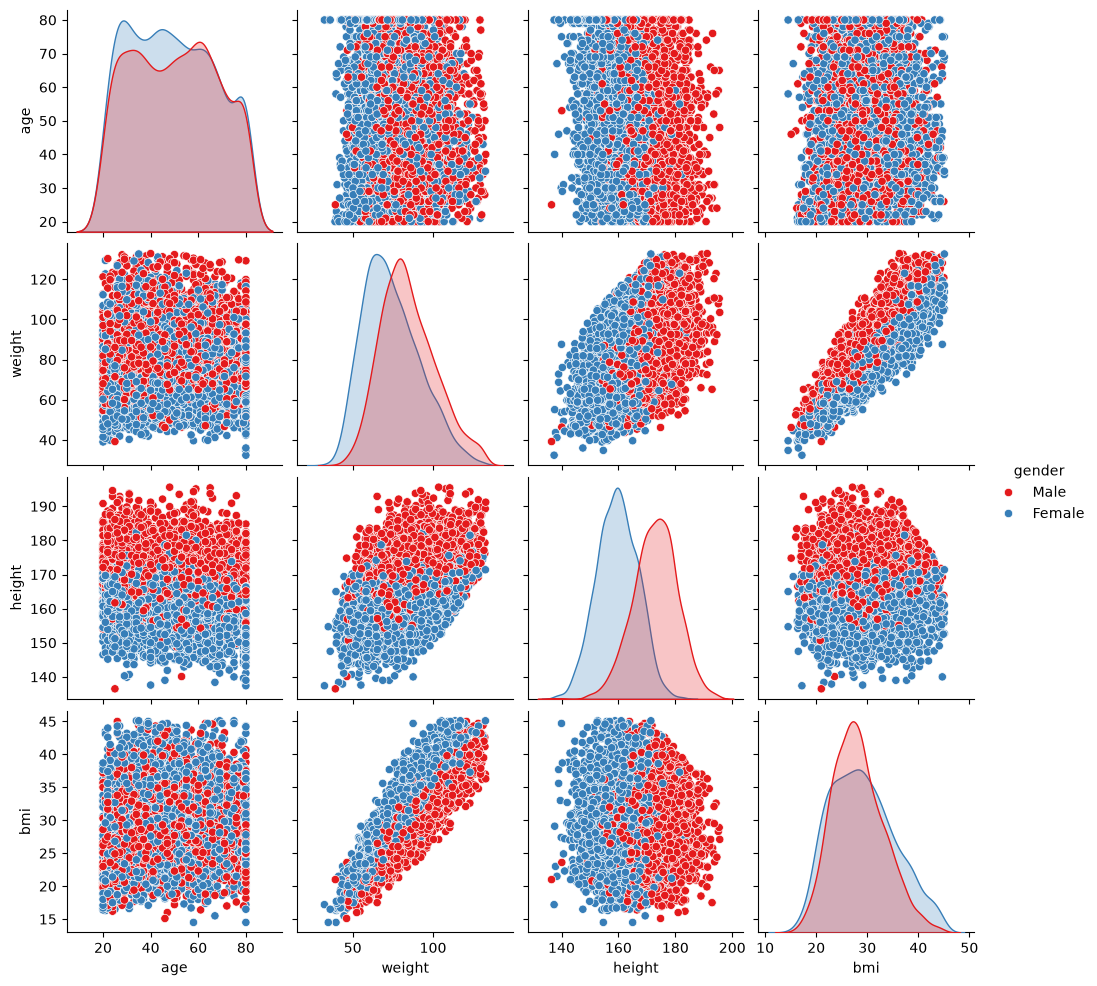

In [33]:
# Pairplot by gender — visualise all variable relationships split by gender
sns.pairplot(data, hue='gender', palette='Set1')



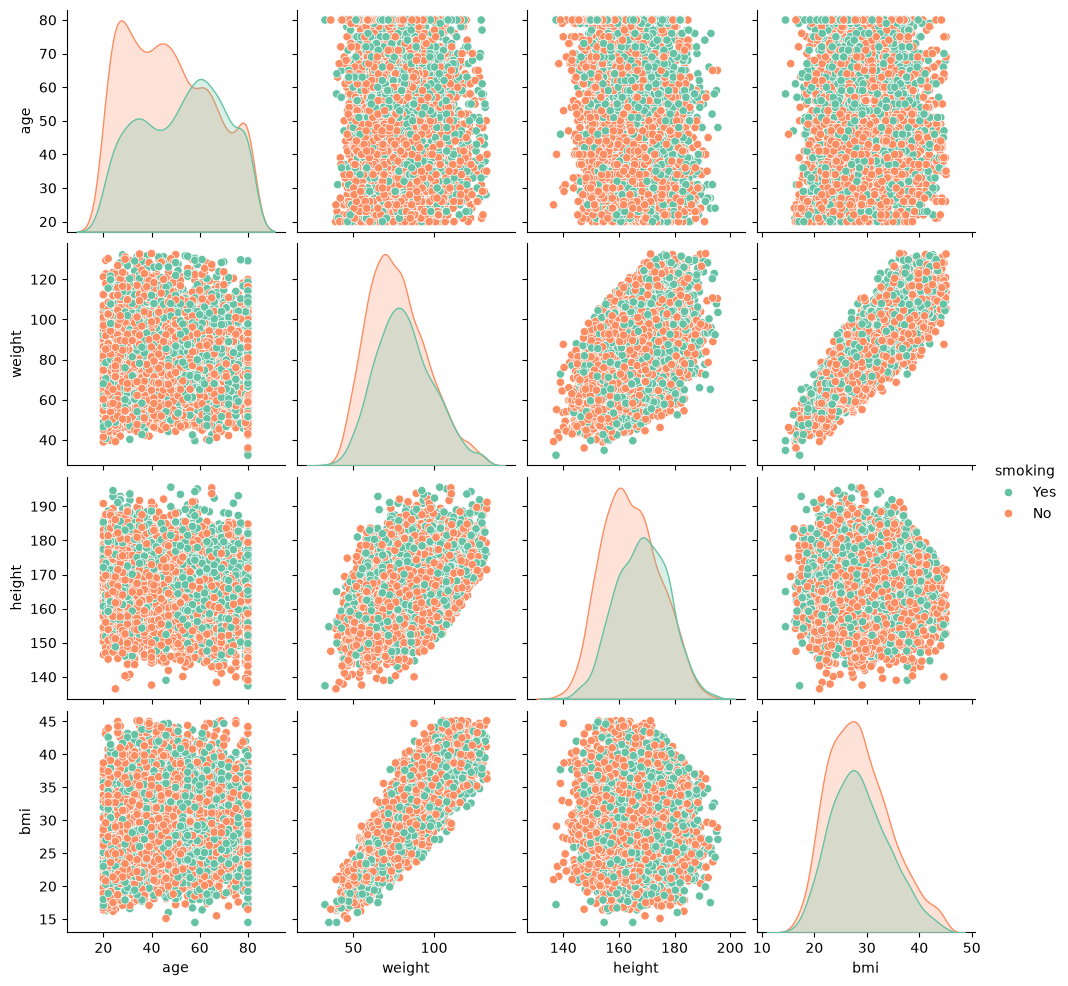

In [34]:
# Pairplot by smoking — visualise all variable relationships split by smoking status
sns.pairplot(data, hue='smoking', palette='Set2')

In [35]:
# Inspect unique age values before binning
sorted(data['age'].unique())




[np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(68),
 np.int64(69),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(73),
 np.int64(74),
 np.int64(75),
 np.int64(76),
 np.int64(77),
 np.int64(78),
 np.int64(79),
 np.int64(80)]

In [36]:
# Bin continuous age into decade bands for group analysis
data['age'] = pd.cut(data.age, [18,30,40,50,60,70,80])

In [37]:
# Smoking proportion and group size by age band and gender
data_cat = data.groupby(['age','gender']).agg({'smoking': [lambda x : np.mean(x == 'Yes'), np.size]})
data_cat.columns = ['proportion','size']
data_cat

proportion  size
age      gender                  
(18, 30] Female    0.228733   529
         Male      0.374439   446
(30, 40] Female    0.279279   444
         Male      0.502347   426
(40, 50] Female    0.255864   469
         Male      0.453333   375
(50, 60] Female    0.423690   439
         Male      0.570439   433
(60, 70] Female    0.379808   416
         Male      0.648910   413
(70, 80] Female    0.326582   395
         Male      0.655440   386

In [38]:
# Mean and std of numerical variables grouped by age band and gender
data_num = data[['gender','age','weight','height','bmi']]
data_num.groupby(['age','gender']).agg(['mean','std'])

weight                 height                  bmi  \
                      mean        std        mean       std       mean   
age      gender                                                          
(18, 30] Female  71.566163  18.074942  161.403970  6.857818  27.428355   
         Male    82.104260  17.384734  174.754036  7.666382  26.861883   
(30, 40] Female  75.427703  18.972633  160.685360  7.193215  29.121847   
         Male    86.431690  17.075469  173.814554  7.634354  28.570892   
(40, 50] Female  76.998081  18.139738  160.221535  7.166239  29.944350   
         Male    87.053067  17.650782  173.614933  7.564800  28.786133   
(50, 60] Female  75.667882  16.414196  159.913440  6.826822  29.543508   
         Male    85.421709  17.061433  172.727714  8.304588  28.549192   
(60, 70] Female  75.177404  16.876943  157.921875  6.854032  30.077885   
         Male    85.186199  16.773681  171.692978  7.227122  28.805327   
(70, 80] Female  70.305063  14.963271  156.220506  6.689105  28.748861   
         Male    80.898705  16.168574  170.287824  7.439598  27.794560   

                           
                      std  
age      gender            
(18, 30] Female  6.477592  
         Male    5.351176  
(30, 40] Female  6.642125  
         Male    5.093793  
(40, 50] Female  6.495185  
         Male    5.105766  
(50, 60] Female  5.878822  
         Male    4.897761  
(60, 70] Female  6.185003  
         Male    4.930047  
(70, 80] Female  5.578536  
         Male    4.716227

In [39]:
# Cross-tabulation of gender vs age band
pd.crosstab(data.gender, data.age, margins=True, margins_name='Total')

age,"(18, 30]","(30, 40]","(40, 50]","(50, 60]","(60, 70]","(70, 80]",Total
gender,,,,,,,
Female,529,444,469,439,416,395,2692
Male,446,426,375,433,413,386,2479
Total,975,870,844,872,829,781,5171


## Hypotheses

### H01: Female age 40–50 and obesity
- **Null (H₀):** Females aged 40–50 are not classified as obese (BMI>30).  
- **Alternative (H₁):** Females aged 40–50 are classified as obese (BMI>30).  


In [40]:
# H01 — One-sample proportion test: are females 40-50 predominantly obese?
from statsmodels.stats.proportion import proportions_ztest

H0 = "proportion obese = 0.5 | Majority are notobese"
H1 = "proportion obese > 0.5 | Majority are obese"

females_40_50 = data[
    (data['gender'] == 'Female') & (data['age'].astype(str) == '(40, 50]')
]
obese = (females_40_50['bmi'] > 30).sum()
n = len(females_40_50)

stat, p = proportions_ztest(obese, n, value=0.5)  # testing against 50% baseline
print(f'Obese: {obese}/{n} ({obese/n*100:.1f}%)')
print(f'Z-stat: {stat:.3f}, p-value: {p:.4f}')
if p < 0.05:
    print(f"Reject H0: {H0}")
else:
    print(f"Fail to reject H0: {H0}")


Obese: 224/469 (47.8%)
Z-stat: -0.971, p-value: 0.3317
Fail to reject H0: proportion obese = 0.5 | Majority are notobese



### H02: Proportion of male vs female smokers
- **Null (H₀):** The proportion of male smokers does not differ significantly from the proportion of female smokers.  
- **Alternative (H₁):** The proportion of male smokers differs significantly from the proportion of female smokers.  



  

In [41]:
# H02 — Chi-square test: do smoking rates differ significantly by gender?
from scipy.stats import chi2_contingency

H0 = "The proportion of male smokers does NOT differ from female smokers"
H1 = "The proportion of male smokers DOES differ from female smokers"
ct = pd.crosstab(data['gender'], data['smoking'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'Chi-square: {chi2:.3f}, p-value: {p:.4f}')
print(f'Male smokers: 53.3%, Female smokers: 31.2%')
if p < 0.05:
    print(f"Reject H0: {H0}")
else:
    print(f"Fail to reject H0: {H0}")


Chi-square: 259.102, p-value: 0.0000
Male smokers: 53.3%, Female smokers: 31.2%
Reject H0: The proportion of male smokers does NOT differ from female smokers


### H03: BMI of males vs females
- **Null (H₀):** The Body Mass Index (BMI) of males and females is statistically similar.  
- **Alternative (H₁):** The Body Mass Index (BMI) of males and females is statistically different.

In [42]:
# H03 — Independent t-test: is BMI significantly different between males and females?
from scipy.stats import ttest_ind

H0 = "BMI of males and females is statistically similar"
H1 = "BMI of males and females is statistically different"

male_bmi = data[data['gender'] == 'Male']['bmi']
female_bmi = data[data['gender'] == 'Female']['bmi']

stat, p = ttest_ind(male_bmi, female_bmi, nan_policy='omit')
print(f'Male BMI mean: {male_bmi.mean():.2f}')
print(f'Female BMI mean: {female_bmi.mean():.2f}')
print(f'T-stat: {stat:.3f}, p-value: {p:.4f}')
if p < 0.05:
    print(f"Reject H0: {H0}")
else:
    print(f"Fail to reject H0: {H0}")

Male BMI mean: 28.21
Female BMI mean: 29.09
T-stat: -5.524, p-value: 0.0000
Reject H0: BMI of males and females is statistically similar
